In [1]:
# Install required libraries
# !pip install shap scikit-learn pandas numpy matplotlib seaborn xgboost dice-ml

# 0. Project Overview & Data Description

This project predicts credit card default using the Default of Credit Card Clients dataset from the UCI Machine Learning Repository. We train an XGBoost model for binary classification and focus on understanding model behavior rather than only prediction accuracy.

To interpret the model, we use DiCE to generate counterfactual explanations that show how feature values must change to alter predictions.

We analyze three representative test instances — a true positive, false positive, and false negative — to observe how the model behaves across correct predictions and different types of errors.

# 1. Data Loading and Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, check for missing values, and look at how the target variable is distributed. Knowing these details is important for effective preprocessing and interpreting the model.

In [2]:
# 1. Install and Import Libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from fairlearn.datasets import fetch_credit_card
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn import metrics

# 2. Load Dataset
data = fetch_credit_card(as_frame=True)
X = data.data
y = data.target.astype(int)

# 3. Rename columns based on UCI official documentation for clarity
meaningful_names = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]
X.columns = meaningful_names

# 4. Check Data
# Check data shape and first few rows
print(f"Data Shape: {X.shape}")

# Data Summary Information: Check data types and identify null values
print(X.info()) 
if X.isnull().sum().sum() == 0:
    print("Check result: No missing values found in the dataset.")

# Key Descriptive Statistics : Review mean, standard deviation, and range
display(X.describe())

# Target Variable Distribution (Default vs. Normal)
print(y.value_counts(normalize=True)) # 0: Paid on time (Normal), 1: Default payment next month (Delinquent)

X.head(5)

Data Shape: (30000, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null 

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


y
0    0.7788
1    0.2212
Name: proportion, dtype: float64


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


# 2. Data Preprocessing: Train-Test Splitting

Before training the model, the dataset is split into training and testing sets using an 80/20 ratio. Stratified sampling is applied to preserve the original class distribution in both sets for reliable evaluation.

In [3]:
# 5. Train/Test Split
# Split data into training and testing sets (80/20).
# Stratified sampling(stratify=y) is applied to preserve class distribution in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Verify the proportion of default (1) and normal (0) in each set.

print("--- Original Data Proportions ---")
print(y.value_counts(normalize=True))

print("\n--- Training Set Proportions ---")
print(y_train.value_counts(normalize=True))

print("\n--- Testing Set Proportions ---")
print(y_test.value_counts(normalize=True))

Training set size: (24000, 23)
Testing set size: (6000, 23)
--- Original Data Proportions ---
y
0    0.7788
1    0.2212
Name: proportion, dtype: float64

--- Training Set Proportions ---
y
0    0.778792
1    0.221208
Name: proportion, dtype: float64

--- Testing Set Proportions ---
y
0    0.778833
1    0.221167
Name: proportion, dtype: float64


# 3. Model Training and Performance Evaluation

### XGBoost Training & Evaluation
In this step, we train an **XGBoost** classifier.

- We use `scale_pos_weight` to reduce the impact of class imbalance (defaults are rarer).
- After training, we compute `confusion matrices` for both the training and testing sets to compare how well the model performs on each and to see whether its predictions behave similarly across datasets.

In [4]:
# 6. Train XGBoost Model (XGBClassifier)

pos = (y_train == 1).sum() # Default
neg = (y_train == 0).sum() # No Default
proportion_class = neg / pos

params_xgb = {
    "n_estimators": 200,
    "max_depth": 8,
    "learning_rate": 0.05,
    "scale_pos_weight": proportion_class,
    "random_state": 42,
}

model = XGBClassifier(**params_xgb,use_label_encoder=True)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

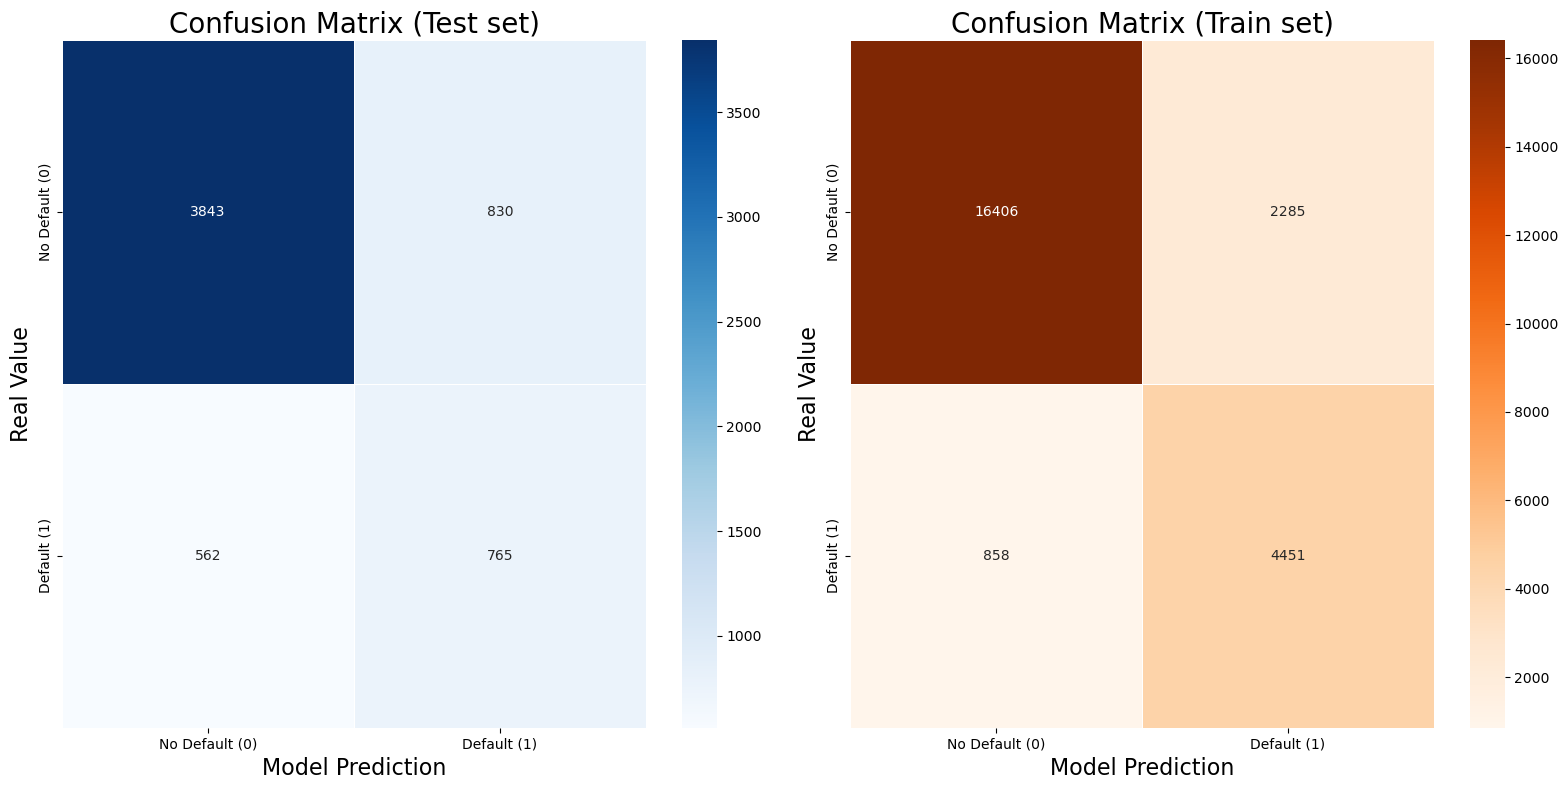

In [5]:
# 7. Comparative Visualization of Confusion Matrices

y_pred_test  = model.predict(X_test)
y_pred_train = model.predict(X_train)

cm_test  = metrics.confusion_matrix(y_true=y_test,  y_pred=y_pred_test,  labels=[0, 1])
cm_train = metrics.confusion_matrix(y_true=y_train, y_pred=y_pred_train, labels=[0, 1])

names_df = ["No Default (0)", "Default (1)"]

cm_df       = pd.DataFrame(data=cm_test,  columns=names_df, index=names_df)
cm_train_df = pd.DataFrame(data=cm_train, columns=names_df, index=names_df)

fig, ax = plt.subplots(ncols=2, figsize=(16, 8))

sns.heatmap(cm_df, fmt="d", annot=True, ax=ax[0], cmap="Blues", linewidths=0.5, linecolor="white")
ax[0].set_xlabel("Model Prediction", size=16)
ax[0].set_ylabel("Real Value", size=16)
ax[0].set_title("Confusion Matrix (Test set)", size=20)

sns.heatmap(cm_train_df, fmt="d", annot=True, ax=ax[1],cmap="Oranges", linewidths=0.5, linecolor="white")
ax[1].set_xlabel("Model Prediction", size=16)
ax[1].set_ylabel("Real Value", size=16)
ax[1].set_title("Confusion Matrix (Train set)", size=20)

plt.tight_layout()
plt.show()


# 4. Model Interpretability with SHAP

 99%|===================| 5959/6000 [01:43<00:00]        

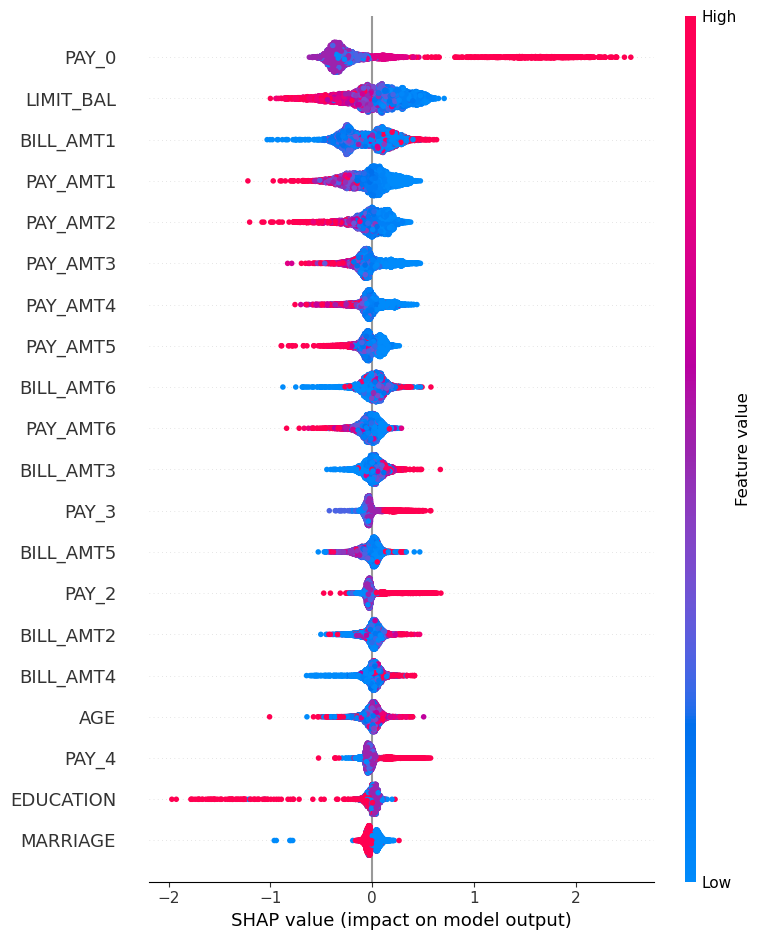

In [6]:
# 8. Use SHAP to identify the most influential features for DiCE explanations.

shap.initjs()

explainer = shap.TreeExplainer(model, X_train, model_output="raw")
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("shap_summary_plot.png", bbox_inches="tight")


# 5. Counterfactual Explanations with DiCE

In this section, we generate **counterfactual explanations** to understand how small changes in input features can alter the model’s prediction.

We use **DiCE** and restrict changes to selected actionable features within realistic ranges so that the explanations remain interpretable and practical.

In [7]:
# Install/Import DiCE
import dice_ml

In [8]:
# 9.Create DiCE data and model objects

# Combine features and label into one dataframe 
df_dice = X.copy()
df_dice['default'] = y.values

# Define continuous features(remaining columns will be treated as categorical)
continuous_features = [
    'LIMIT_BAL', 'AGE',  "PAY_0", 
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

categorical_features = [c for c in X.columns if c not in continuous_features]

data_dice = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=continuous_features,
    categorical_features=categorical_features,
    outcome_name='default'
)

model_dice = dice_ml.Model(model=model, backend='sklearn')
dice_exp = dice_ml.Dice(data_dice, model_dice, method='random')


In [9]:
# 10. Select representative test instances (TP, FP, FN)

# Boundary-based selection (near p=0.5)
proba = model.predict_proba(X_test)[:, 1]
y_pred_test = (proba >= 0.5).astype(int)   # proba와 일관성 유지

results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred_test
results["p_default"] = proba
results["dist_to_boundary"] = np.abs(results["p_default"] - 0.5)

pay_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]
MIN_PAY_SUM = 300

def pick_closest(cand_df):
    cand_df = cand_df.copy()
    cand_df = cand_df[cand_df[pay_cols].sum(axis=1) > MIN_PAY_SUM]
    if cand_df.empty:
        return None
    return cand_df["dist_to_boundary"].idxmin()

tp_idx = pick_closest(results[(results["actual"]==1) & (results["predicted"]==1)])
fp_idx = pick_closest(results[(results["actual"]==0) & (results["predicted"]==1)])
fn_idx = pick_closest(results[(results["actual"]==1) & (results["predicted"]==0)])

indices = [tp_idx, fp_idx, fn_idx]
case_names = [
    "True Positive (Correct): Default → Default",
    "False Positive (Error): Non-default → Default",
    "False Negative (Error): Default → Non-default"
]


# Define realistic ranges for counterfactual search
def make_query_instance(idx):
    qi = X_test.loc[[idx]].copy() 
    qi = qi.fillna(X_train.median(numeric_only=True))
    qi = qi[X_train.columns]       
    return qi

# Define actionable features allowed to change
features_to_vary = ["PAY_0","LIMIT_BAL"] + pay_cols

def build_permitted_range(query_instance):
    pr = {}

    # PAY_0: repayment status (discrete levels).
    # Restricted to integer range to avoid unrealistic fractional values in counterfactuals.
    pr["PAY_0"] = [-2, 2]  

    # LIMIT_BAL: credit limit should not increase (only allow decrease or same)
    base_lb = float(query_instance["LIMIT_BAL"].iloc[0])
    pr["LIMIT_BAL"] = [0.0, base_lb]

    # PAY_AMT*: cap payments using both domain constraint and data constraint
    # - domain rule: payment should not exceed 30% of credit limit
    # - data rule: payment should not exceed 99th percentile of observed values
    q99 = {c: float(X[c].quantile(0.99)) for c in pay_cols}
    cap_util = 0.30 * base_lb

    for col in pay_cols:
        pr[col] = [0.0, min(cap_util, q99[col])]

    return pr

def make_sparse_changes_table(query_instance, cfs_df, outcome_col="default"):
    # Original row + CF rows where unchanged values are replaced by "-"


    
    orig_row = query_instance.iloc[0]
    out = cfs_df.copy()

    feat_cols = [c for c in out.columns if c != outcome_col]

    for c in feat_cols:
        a = orig_row[c]
        out[c] = out[c].apply(lambda v: "-" if ((pd.isna(a) and pd.isna(v)) or (v == a)) else v)

    orig_display = orig_row.to_frame().T
    orig_display.index = ["Original"]

    # ensure outcome col exists for alignment
    if outcome_col in out.columns and outcome_col not in orig_display.columns:
        orig_display[outcome_col] = "-"

    orig_display = orig_display[out.columns]
    return pd.concat([orig_display, out], axis=0)


# Generate counterfactual explanations for each case
for idx, name in zip(indices, case_names):

    query_instance = make_query_instance(idx)
    permitted_range = build_permitted_range(query_instance)

    # Flip prediction direction depending on case type
    desired_class = 1 if "False Negative" in name else 0

    try:
        
        cf = dice_exp.generate_counterfactuals(
            query_instance,
            total_CFs=2,
            desired_class=desired_class,
            features_to_vary=features_to_vary,
            permitted_range=permitted_range,
            random_seed=42,
            sample_size=10000
        )


        CF_dice = cf.cf_examples_list[0].final_cfs_df.copy()
        pred_cf = model.predict_proba(CF_dice.drop(columns=["default"]))
        CF_dice[["P(Non-Default)", "P(Default)"]] = np.round(pred_cf, 4)
    
        print("\n" + "="*80)
        print(name, "| idx:", idx)

        # cf.visualize_as_dataframe(show_only_changes=True)
        sparse_view = make_sparse_changes_table(
            query_instance, 
            cf.cf_examples_list[0].final_cfs_df, 
            outcome_col="default"
            )
        print("Original + Counterfactuals (only changes shown):")
        display(sparse_view)
        

    except Exception as e:
        print("\n" + "="*80)
        print(name, "| idx:", idx, "→ no counterfactual found")
        print("Error:", str(e))


100%|██████████| 1/1 [00:02<00:00,  2.03s/it]


True Positive (Correct): Default → Default | idx: 5875
Original + Counterfactuals (only changes shown):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
Original,340000,2,2,2,33,0,0,0,0,0,...,311784,318320,325028,10300,10302,10365,10750,11150,11271,-
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,4234,-,-,21625,0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,68026,-,-,-,-,0


100%|██████████| 1/1 [00:02<00:00,  2.03s/it]


False Positive (Error): Non-default → Default | idx: 16362
Original + Counterfactuals (only changes shown):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
Original,360000,2,2,1,33,1,-1,2,2,-2,...,-9,-9,-9,2645,2,0,0,0,0,-
0,112581,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,65155,-,-,-,0
1,208524,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0


100%|██████████| 1/1 [00:01<00:00,  1.97s/it]


False Negative (Error): Default → Non-default | idx: 27189
Original + Counterfactuals (only changes shown):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
Original,120000,1,2,2,29,1,-1,-1,-1,0,...,652,326,326,652,326,652,0,326,326,-
0,-,-,-,-,-,2,-,-,-,-,...,-,-,-,-,-,-,25034,-,-,1
1,-,-,-,-,-,2,-,-,-,-,...,-,-,-,-,-,-,-,-,16676,1


## Counterfactual Analysis Summary

To understand the local behavior of the model, we analyzed representative TP, FP, and FN instances closest to the decision boundary (p ≈ 0.5).

---

### True Positive (Correct)
**Original prediction:** Default  

**Objective** :

Identify what realistic feature changes would be required for this instance to be classified as non-default.

**Result**

The prediction flips when either of the following changes occur:

- **PAY_AMT3 decreases from 10365 → 4234 AND PAY_AMT6 increases from 11271 → 21625**
- **PAY_AMT2 increases from 10302 → 68026**

**Interpretation**

- The model’s decision can be reversed, but only if **payments increase/decrease a lot**; small changes are not enough.

**Insight** :
- This customer’s PAY_AMT1–PAY_AMT6 values (10300, 10302, 10365, 10750, 11150, 11271) are consistently around 10,000, indicating stable payment behavior. However, the model suggests that large fluctuations in payments are required to change the prediction, which may be difficult to apply in real-world scenarios.
- This implies that customers with highly variable payment amounts are more likely to be classified as non-default than those with stable payments, which appears inconsistent with realistic financial behavior.
---

### False Positive (Error)

Original prediction: **Default**

**Objective** :

Determine what minimal realistic improvements would allow this instance to be correctly classified as non-default.

**Result**

The prediction flips when:

- **LIMIT_BAL decreases from 360000 → 112581 AND PAY_AMT3 increases from 0 → 65155**
- **LIMIT_BAL decreases from 360000 → 208524**

**Interpretation**
- For this false positive case, the model can be corrected in two ways:
  1. Substantially decreasing the credit limit while simultaneously increasing the payment amount, or
  2. Adjusting only the credit limit.


**Insight**

- This customer is actually a non-default case but was predicted as default. As observed from the SHAP results, the credit limit appears to have had a strong influence on the model’s decision.
Therefore, adjusting how the model weights or interprets the credit limit feature—for example, by reducing its influence—could help improve prediction accuracy.
- Although this instance was misclassified, modifying the customer’s credit limit could potentially reduce their actual future default risk.

---

### False Negative (Error)

Original prediction: **Non-default**

**Objective** :

Identify what feature changes would cause the model to correctly classify this instance as default.


**Result**

The prediction flips when:

- **PAY_0 increases from 1 → 2 AND PAY_AMT4 increases from 0 → 25034**
- **PAY_0 increases from 1 → 2 AND PAY_AMT6 increases from 326 → 16676**

**Interpretation**

- Increasing delinquency status together with a large payment change pushes the model toward predicting default.


**Insight**
- The customer actually had one month of delinquency (PAY_0 = 1), but their typical payment amounts (652, 326, 652, 0, 326, 326) were relatively small compared to their credit limit of 120,000.
Therefore, despite having a one-month delay, the model likely classified this customer as non-default because their payment amounts were consistently low.
- Since this instance lies near the decision boundary, the customer could be classified as default if another delinquency occurs. However, the model’s requirement that PAY_AMT4 (or PAY_AMT6) must change drastically to flip the prediction appears unrealistic, suggesting that further calibration of payment-related features may be necessary.

---

### Overall Interpretation

Although counterfactual explanations can successfully change predictions, some proposed changes are quite drastic and may not be realistic. This indicates that counterfactual methods focus on the mathematical changes needed to cross the decision boundary instead of considering practical feasibility.

In this experiment, the results indicate that the model’s decisions seem to be influenced locally by a small group of features instead of the entire financial profile.

In practical settings, adding more specific constraints and feasibility factors may help create more realistic and useful recommendations.

Overall, this experiment demonstrates that even when some counterfactual instances are not practically plausible, DiCE is still an effective tool for analyzing local model behavior and identifying influential features. While the generated counterfactuals may not always represent realistic action plans, they are valuable for understanding model sensitivity and decision logic.
